In [ ]:
print("Hello World")

Hello World


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
data = pd.read_csv('spam.csv', encoding='latin-1')

data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
# Keep only useful columns
data = data[['v1', 'v2']]

# Rename columns
data.columns = ['label', 'message']

# Convert spam/ham into numbers
data['label'] = data['label'].map({'ham': 0, 'spam': 1})

# Show first 5 rows
data.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# Input and output
X = data['message']
y = data['label']

# Convert text into numbers using TF-IDF
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(X)

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data split successful ")

Data split successful 


In [ ]:
# Train Logistic Regression model

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

# Predictions
lr_predictions = lr_model.predict(X_test)

print("Logistic Regression Model Trained Successfully ")

Logistic Regression Model Trained Successfully 


In [ ]:
# Train Random Forest model

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

# Predictions
rf_predictions = rf_model.predict(X_test)

print("Random Forest Model Trained Successfully ")

Random Forest Model Trained Successfully 


In [ ]:
# Logistic Regression Metrics

print("LOGISTIC REGRESSION RESULTS")
print("Accuracy:", accuracy_score(y_test, lr_predictions))
print("Precision:", precision_score(y_test, lr_predictions))
print("Recall:", recall_score(y_test, lr_predictions))
print("F1 Score:", f1_score(y_test, lr_predictions))
print("ROC-AUC:", roc_auc_score(y_test, lr_predictions))

print("\n-----------------------------------\n")

# Random Forest Metrics

print("RANDOM FOREST RESULTS")
print("Accuracy:", accuracy_score(y_test, rf_predictions))
print("Precision:", precision_score(y_test, rf_predictions))
print("Recall:", recall_score(y_test, rf_predictions))
print("F1 Score:", f1_score(y_test, rf_predictions))
print("ROC-AUC:", roc_auc_score(y_test, rf_predictions))

LOGISTIC REGRESSION RESULTS
Accuracy: 0.9632286995515695
Precision: 1.0
Recall: 0.7266666666666667
F1 Score: 0.8416988416988417
ROC-AUC: 0.8633333333333333

-----------------------------------

RANDOM FOREST RESULTS
Accuracy: 0.9766816143497757
Precision: 1.0
Recall: 0.8266666666666667
F1 Score: 0.9051094890510949
ROC-AUC: 0.9133333333333333


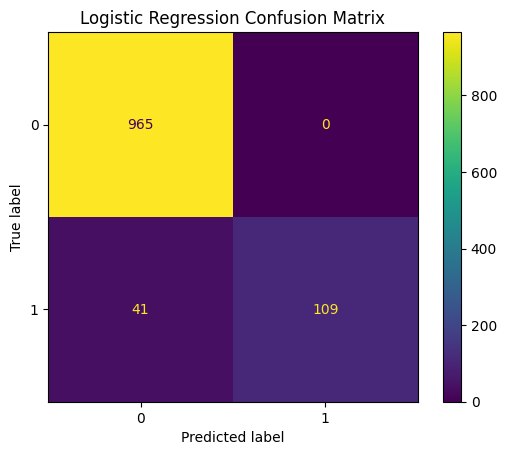

In [ ]:
# Confusion Matrix for Logistic Regression

cm = confusion_matrix(y_test, lr_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")

plt.show()

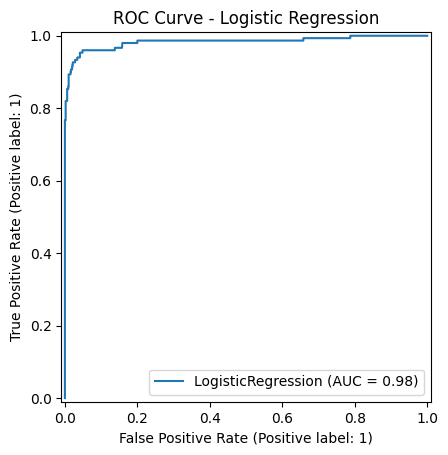

In [ ]:
from sklearn.metrics import RocCurveDisplay

# ROC Curve for Logistic Regression

RocCurveDisplay.from_estimator(lr_model, X_test, y_test)

plt.title("ROC Curve - Logistic Regression")

plt.show()

In [ ]:
print("Conclusion")
print("Both Logistic Regression and Random Forest performed well for spam email classification.")
print("The models achieved high accuracy and successfully identified spam messages.")
print("This project demonstrates the use of machine learning for text classification tasks.")

Conclusion
Both Logistic Regression and Random Forest performed well for spam email classification.
The models achieved high accuracy and successfully identified spam messages.
This project demonstrates the use of machine learning for text classification tasks.


In [1]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [3]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, LSTM

from sklearn.model_selection import train_test_split

In [8]:
import pandas as pd
import numpy as np

In [9]:
# Load dataset
data = pd.read_csv('spam.csv', encoding='latin-1')

# Keep useful columns only
data = data[['v1', 'v2']]

# Rename columns
data.columns = ['label', 'message']

# Convert labels into numbers
data['label'] = data['label'].map({'ham': 0, 'spam': 1})

# Show first 5 rows
data.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
# Separate input and output
X = data['message']
y = data['label']

# Tokenization
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(X)

X_sequences = tokenizer.texts_to_sequences(X)

# Padding
X_padded = pad_sequences(X_sequences, maxlen=100)

print("Tokenization and Padding Done")

Tokenization and Padding Done


In [11]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X_padded,
    y,
    test_size=0.2,
    random_state=42
)

print("Data Split Successful ")

Data Split Successful 


In [13]:
# Build Deep Learning Model

model = Sequential()

# Embedding Layer
model.add(Embedding(input_dim=5000, output_dim=64, input_length=100))

# LSTM Layer
model.add(LSTM(64))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

# Compile Model
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("Deep Learning Model Created ")

Deep Learning Model Created 


In [14]:
# Train Model

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.9446 - loss: 0.1738 - val_accuracy: 0.9830 - val_loss: 0.0684
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.9890 - loss: 0.0394 - val_accuracy: 0.9839 - val_loss: 0.0611
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.9964 - loss: 0.0163 - val_accuracy: 0.9812 - val_loss: 0.0678
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - accuracy: 0.9975 - loss: 0.0083 - val_accuracy: 0.9812 - val_loss: 0.0636
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.9984 - loss: 0.0047 - val_accuracy: 0.9821 - val_loss: 0.0520


In [15]:
# Evaluate Model

loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9821 - loss: 0.0520
Test Accuracy: 0.9820627570152283
Test Loss: 0.05199597775936127


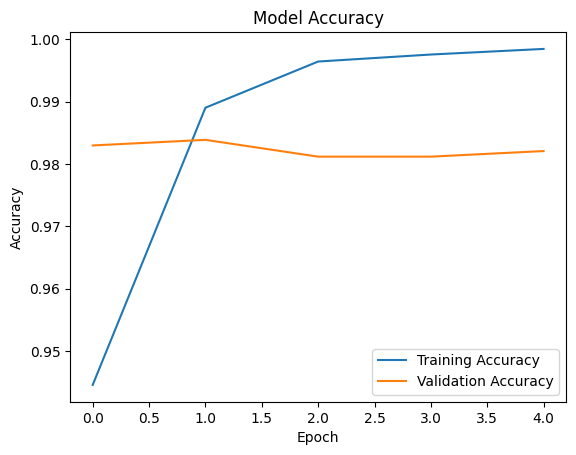

In [16]:
# Plot Training Accuracy

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

In [17]:
# Save Model

model.save("spam_classifier_model.h5")

print("Model Saved Successfully ")

Model Saved Successfully 
